twitter에서 Iphone, Galaxy에 대한 tweet을 감정분석

In [1]:
# @title 단계 1. 환경 설정
# 필요한 라이브러리 설치
!pip install -q "transformers<5.0" "tokenizers<0.21" datasets accelerate

# 라이브러리 임포트
from datasets import load_dataset, Dataset
from transformers import pipeline
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# GPU 사용 가능 여부 확인
device = 0 if torch.cuda.is_available() else -1
print(f"사용 가능한 디바이스: {'GPU' if device == 0 else 'CPU'}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Hugging Face Hub에서 tweet_eval 데이터셋의 sentiment 서브셋을 불러온다.
split="train"으로 가져옴

In [2]:
# @title 단계 2. 데이터셋 로드 및 필터링

# tweet_eval 데이터셋 로드 (sentiment 서브셋)
raw_dataset = load_dataset("tweet_eval", "sentiment", split="train")

# Pandas DataFrame으로 변환
df = pd.DataFrame(raw_dataset)

print("전체 데이터셋 크기:", len(df))
print("\n데이터 샘플 확인:")
display(df.head(3))
print("\n컬럼 목록:", df.columns.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

전체 데이터셋 크기: 45615

데이터 샘플 확인:


,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1



컬럼 목록: ['text', 'label']


str.contains로 키워드가 포함된 트윗만 걸러내기. case=False -> 대소문자 구분 없이 검색, na=False -> 빈 값은 False로 처리

In [3]:
# @title 단계 2-2. iPhone / Galaxy 필터링

# 키워드 필터링
iphone_mask = df['text'].str.contains('iphone|apple', case=False, na=False)
galaxy_mask = df['text'].str.contains('galaxy|samsung', case=False, na=False)

# 브랜드 라벨 추가
df_iphone = df[iphone_mask].copy()
df_iphone['brand'] = 'iPhone'

df_galaxy = df[galaxy_mask].copy()
df_galaxy['brand'] = 'Galaxy'

# 결과 확인
print(f"iPhone 관련 트윗 수: {len(df_iphone)}")
print(f"Galaxy 관련 트윗 수: {len(df_galaxy)}")

print("\n iPhone 트윗 샘플:")
print(df_iphone['text'].values[0])
print("\n Galaxy 트윗 샘플:")
print(df_galaxy['text'].values[0])

iPhone 관련 트윗 수: 481
Galaxy 관련 트윗 수: 161

 iPhone 트윗 샘플:
iPhone 6s Launch: More Details Leak Ahead of Apple's September 9 Event: iPhone 6s launch on Wednesday is just ...

 Galaxy 트윗 샘플:
Reminder: Samsung Unveils the Galaxy Note 5 and S6 Edge+ Tomorrow Morning! - - #tech #news...


In [4]:
# @title 단계 2-3. 합치기 & 샘플링

# 두 브랜드 합치기
combined_df = pd.concat([df_iphone, df_galaxy]).reset_index(drop=True)

# 100개 샘플링 (브랜드 비율 유지)
sampled_df = combined_df.groupby('brand', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(100 * len(x) / len(combined_df))), random_state=42)
).reset_index(drop=True)

# label 숫자 → 텍스트로 변환
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
sampled_df['original_label'] = sampled_df['label'].map(label_map)

# Hugging Face Dataset으로 변환
sampled_dataset = Dataset.from_pandas(sampled_df[['text', 'brand', 'original_label']].reset_index(drop=True))

print(f"최종 샘플 수: {len(sampled_dataset)}")
print(f"\n브랜드별 샘플 수:")
print(sampled_df['brand'].value_counts())
print(f"\n데이터 샘플 확인:")
display(sampled_df[['text', 'brand', 'original_label']].head(5))

최종 샘플 수: 99

브랜드별 샘플 수:
brand
iPhone    74
Galaxy    25
Name: count, dtype: int64

데이터 샘플 확인:


/tmp/ipykernel_755/2035862155.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = combined_df.groupby('brand', group_keys=False).apply(


,text,brand,original_label
0,Because @user still hasn't put a pre order but...,Galaxy,neutral
1,"""Sprint getting Samsung Galaxy Tab 2 10.1 with...",Galaxy,neutral
2,Samsung's Galaxy Note 5 will be released this ...,Galaxy,positive
3,"It may not be coming to the UK, but here's wha...",Galaxy,neutral
4,In a nutshell: 11 things we think we know abou...,Galaxy,neutral


In [5]:
# @title 단계 3. 감정 분석 모델 파이프라인 로드

# 트위터 전용 감정 분석 모델 로드
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

print("감정 분석 파이프라인 로드 완료!")

# 테스트
test_result = sentiment_pipeline("iPhone camera is absolutely amazing!")
print(f"\n테스트 결과: {test_result}")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

감정 분석 파이프라인 로드 완료!

테스트 결과: [{'label': 'positive', 'score': 0.982687771320343}]


In [6]:
# @title 단계 4. map 함수로 감정 분석 적용

# 감정 분석 함수 정의
def analyze_sentiment(example):
    result = sentiment_pipeline(
        example['text'],
        truncation=True,    # 트윗이 너무 길면 자동으로 잘라줌
        max_length=512
    )
    example['predicted_sentiment'] = result[0]['label']
    example['sentiment_score'] = round(result[0]['score'], 4)
    return example

print("감정 분석 시작... (잠시 기다려주세요)")

# map 함수로 전체 데이터셋에 적용
final_dataset = sampled_dataset.map(analyze_sentiment)

print("감정 분석 완료!")

# 결과 확인
final_df = pd.DataFrame(final_dataset)
print(f"\n결과 샘플:")
display(final_df[['brand', 'text', 'predicted_sentiment', 'sentiment_score']].head(5))

감정 분석 시작... (잠시 기다려주세요)


Map:   0%|          | 0/99 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


감정 분석 완료!

결과 샘플:


,brand,text,predicted_sentiment,sentiment_score
0,Galaxy,Because @user still hasn't put a pre order but...,negative,0.5622
1,Galaxy,"""Sprint getting Samsung Galaxy Tab 2 10.1 with...",neutral,0.6446
2,Galaxy,Samsung's Galaxy Note 5 will be released this ...,positive,0.7075
3,Galaxy,"It may not be coming to the UK, but here's wha...",neutral,0.5677
4,Galaxy,In a nutshell: 11 things we think we know abou...,neutral,0.7651


현재 폰트: ['NanumGothic']


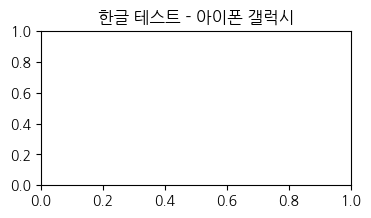

In [9]:
# @title 한글 폰트 설치 (맨 처음에 한 번만 실행)
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 캐시 강제 초기화
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 적용 확인
print("현재 폰트:", plt.rcParams['font.family'])
fig, ax = plt.subplots(figsize=(4, 2))
ax.set_title('한글 테스트 - 아이폰 갤럭시')
plt.show()

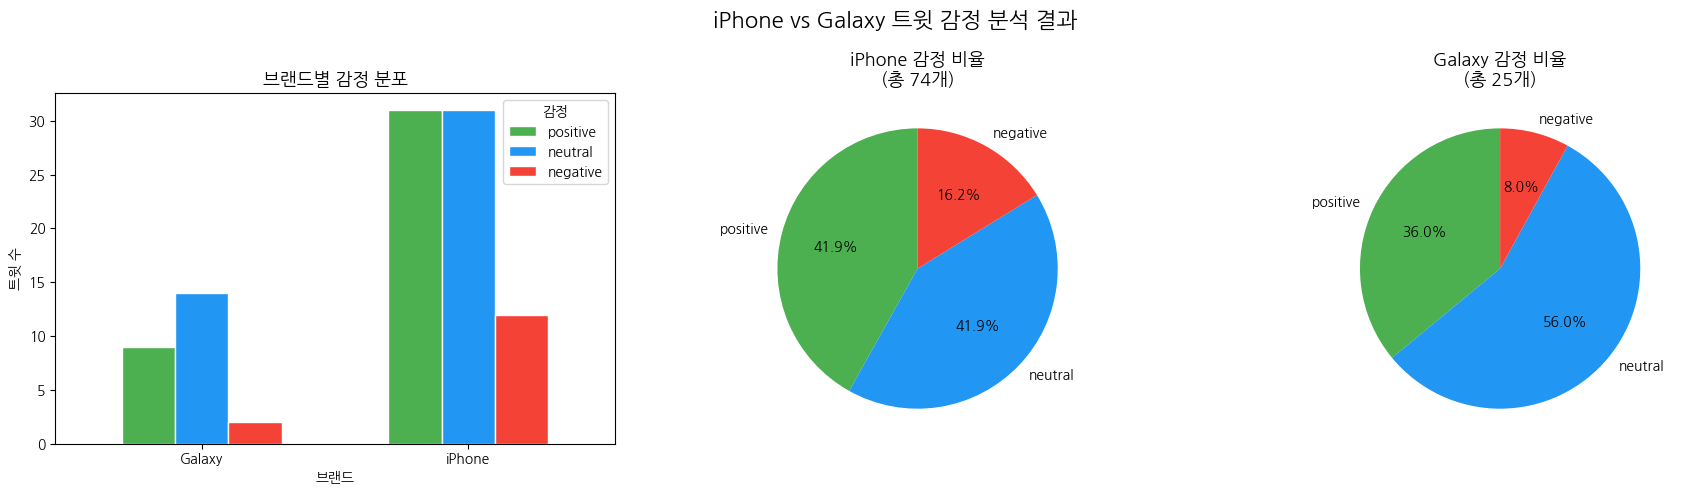

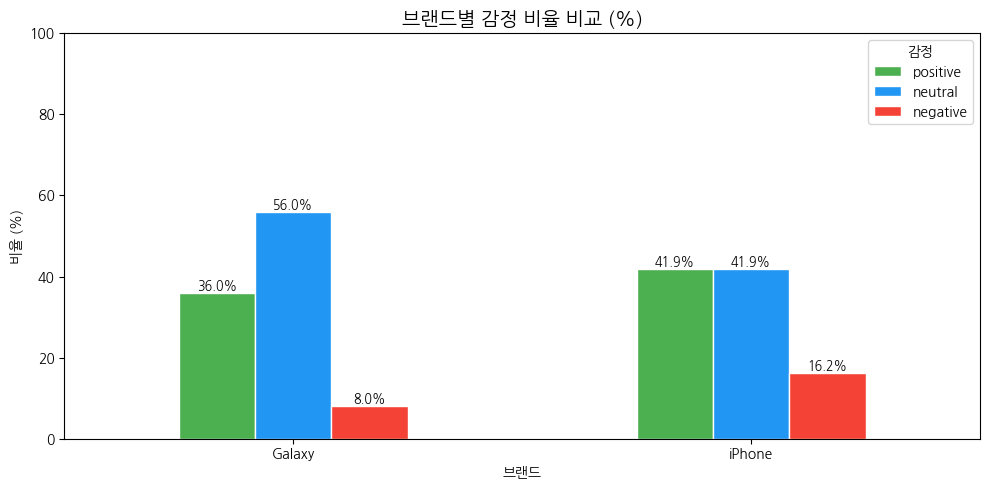


📊 브랜드별 감정 비율 요약 (%):


predicted_sentiment,positive,neutral,negative
brand,,,
Galaxy,36.0%,56.0%,8.0%
iPhone,41.9%,41.9%,16.2%



📌 인사이트:

iPhone
  긍정: 41.9%  중립: 41.9%  부정: 16.2%
  → 가장 많은 감정: positive

Galaxy
  긍정: 36.0%  중립: 56.0%  부정: 8.0%
  → 가장 많은 감정: neutral


In [10]:
# @title 단계 5. 시각화 (한글 폰트 수정 + 비율 분석)

# 한글 폰트 설치
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)

# 나눔 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

sentiment_order = ['positive', 'neutral', 'negative']
colors = {'positive': '#4CAF50', 'neutral': '#2196F3', 'negative': '#F44336'}

# ── 그래프 1~3 ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('iPhone vs Galaxy 트윗 감정 분석 결과', fontsize=16, fontweight='bold')

# 그래프 1. 브랜드별 감정 분포 (Count)
sentiment_counts = final_df.groupby(['brand', 'predicted_sentiment']).size().unstack(fill_value=0)
sentiment_counts = sentiment_counts.reindex(columns=sentiment_order, fill_value=0)
sentiment_counts.plot(
    kind='bar', ax=axes[0],
    color=[colors[s] for s in sentiment_order],
    edgecolor='white', width=0.6
)
axes[0].set_title('브랜드별 감정 분포', fontsize=13)
axes[0].set_xlabel('브랜드')
axes[0].set_ylabel('트윗 수')
axes[0].set_xticklabels(['Galaxy', 'iPhone'], rotation=0)
axes[0].legend(title='감정')

# 그래프 2. iPhone 감정 비율 파이차트
iphone_df = final_df[final_df['brand'] == 'iPhone']
iphone_counts = iphone_df['predicted_sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
axes[1].pie(iphone_counts, labels=sentiment_order,
            colors=[colors[s] for s in sentiment_order],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'iPhone 감정 비율\n(총 {len(iphone_df)}개)', fontsize=13)

# 그래프 3. Galaxy 감정 비율 파이차트
galaxy_df = final_df[final_df['brand'] == 'Galaxy']
galaxy_counts = galaxy_df['predicted_sentiment'].value_counts().reindex(sentiment_order, fill_value=0)
axes[2].pie(galaxy_counts, labels=sentiment_order,
            colors=[colors[s] for s in sentiment_order],
            autopct='%1.1f%%', startangle=90)
axes[2].set_title(f'Galaxy 감정 비율\n(총 {len(galaxy_df)}개)', fontsize=13)

plt.tight_layout()
plt.show()

# ── 그래프 4. 브랜드별 감정 비율 비교 막대그래프 ──────
fig2, ax = plt.subplots(figsize=(10, 5))

ratio_df = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100
ratio_df.plot(kind='bar', ax=ax,
              color=[colors[s] for s in sentiment_order],
              edgecolor='white', width=0.5)

ax.set_title('브랜드별 감정 비율 비교 (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('브랜드')
ax.set_ylabel('비율 (%)')
ax.set_xticklabels(['Galaxy', 'iPhone'], rotation=0)
ax.legend(title='감정')
ax.set_ylim(0, 100)

# 막대 위에 퍼센트 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.tight_layout()
plt.show()

# ── 수치 요약 ──────────────────────────────────────
print("\n📊 브랜드별 감정 비율 요약 (%):")
ratio_summary = ratio_df.round(1).astype(str) + '%'
display(ratio_summary)

print("\n📌 인사이트:")
for brand in ['iPhone', 'Galaxy']:
    row = ratio_df.loc[brand]
    print(f"\n{brand}")
    print(f"  긍정: {row['positive']:.1f}%  중립: {row['neutral']:.1f}%  부정: {row['negative']:.1f}%")
    dominant = row.idxmax()
    print(f"  → 가장 많은 감정: {dominant}")

In [29]:
!pip install nbconvert -q

!jupyter nbconvert --to script "/content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.ipynb to script
[NbConvertApp] Writing 7183 bytes to /content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.txt


In [30]:
import os

os.rename(
    '/content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.txt',
    '/content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.py'
)
print("완료!")

완료!


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git config --global user.email "amy041015@daum.net"
!git config --global user.name "dokong22222"

Mounted at /content/drive


In [7]:
import json

# 노트북 파일 열기
with open('/content/drive/MyDrive/git/4-huggingface/Assignment/huggingface.ipynb', 'r') as f:
    content = f.read()

# 토큰 패턴 찾기
if 'ghp_' in content:
    # 토큰이 있는 위치 찾기
    idx = content.find('ghp_')
    print("토큰 발견!")
    print("주변 텍스트:", content[idx-50:idx+60])
else:
    print("토큰 없음")

토큰 없음


In [14]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')

%cd /content/drive/MyDrive/git/4-huggingface

!git remote set-url origin https://{token}@github.com/dokong22222/4-huggingface.git
!git push origin master:hateslop4 --force

/content/drive/MyDrive/git/4-huggingface
Enumerating objects: 14, done.
Counting objects: 100% (14/14), done.
Delta compression using up to 2 threads
Compressing objects: 100% (13/13), done.
Writing objects: 100% (14/14), 117.04 KiB | 2.05 MiB/s, done.
Total 14 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), done.
To https://github.com/dokong22222/4-huggingface.git
 + 315b71a...d4f0998 master -> hateslop4 (forced update)


In [16]:
%cd /content/drive/MyDrive/git/4-huggingface

# 원격 브랜치 가져오기
!git fetch origin

# 브랜치 목록 확인
!git branch -a

/content/drive/MyDrive/git/4-huggingface
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 23 (delta 8), reused 15 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (23/23), 57.79 KiB | 167.00 KiB/s, done.
From https://github.com/dokong22222/4-huggingface
   d4f0998..7a5a70b  hateslop4  -> origin/hateslop4
 * [new branch]      main       -> origin/main
* master
  remotes/origin/hateslop4
  remotes/origin/main


In [15]:
%cd /content/drive/MyDrive/git/4-huggingface

# main 브랜치로 이동
!git checkout main

# hateslop4 브랜치를 강제로 머지
!git merge hateslop4 --allow-unrelated-histories -m "Merge hateslop4 into main"

# push
!git push origin main

/content/drive/MyDrive/git/4-huggingface
error: pathspec 'main' did not match any file(s) known to git
merge: hateslop4 - not something we can merge

Did you mean this?
	origin/hateslop4
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/dokong22222/4-huggingface.git'
